In [42]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

import sympy as sp
from sympy.abc import x, y, z

sp.init_printing()
import sys
from sympy.plotting import plot 

In [2]:

from sympy.abc import a, b
f1, f2 = sp.symbols("p_0 p_1")
a,  b  = sp.symbols(r"\Gamma_\uparrow \Gamma_\downarrow")
A = sp.Matrix(2, 2, [-a, b, a, -b])

f = sp.Matrix(2, 1, [f1, f2])

In [3]:
A, f

⎛⎡-\Gamma_\uparrow  \Gamma_\downarrow ⎤  ⎡p₀⎤⎞
⎜⎢                                    ⎥, ⎢  ⎥⎟
⎝⎣\Gamma_\uparrow   -\Gamma_\downarrow⎦  ⎣p₁⎦⎠

In [4]:
f, g = sp.symbols("p_0 p_1", cls = sp.Function)
t    = sp.symbols("t")

In [5]:
eq1 = sp.Eq(f(t).diff(t), - a * f(t) + b * g(t))
eq2 = sp.Eq(g(t).diff(t),   a * f(t) - b * g(t))

eq1, eq2

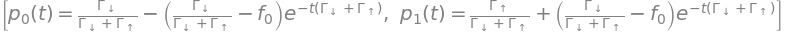

In [6]:
from sympy.solvers.ode.systems import dsolve_system
f0 = sp.symbols("f_0")
g0 = 1 - f0
sols = dsolve_system([eq1, eq2], [f(t), g(t)], ics = {f(0): f0, g(0): g0})
sols[0]

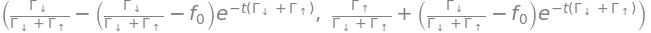

In [75]:
f_sol = sols[0][0].rhs
g_sol = sols[0][1].rhs


subs = {a: 1 / 10, b: 1 / 100, f0: 0.5, g0: 0.5}

f_sol, g_sol

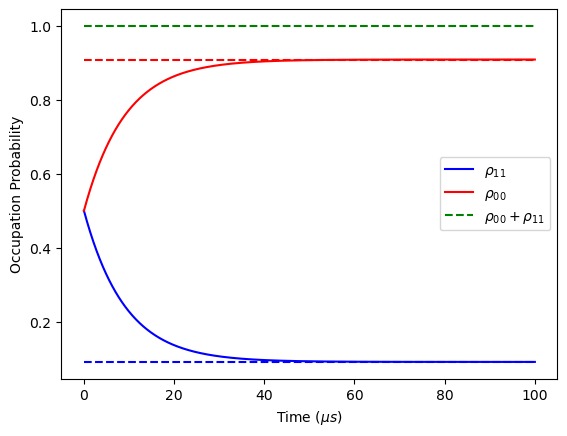

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming f_sol, g_sol are sympy expressions and subs is a dictionary of substitutions
# and that t is the variable in the expressions

# Substitute values into the expressions
f_subs = f_sol.subs(subs)
g_subs = g_sol.subs(subs)
fg_sum_subs = (f_sol + g_sol).subs(subs)

# Create a range for t
t_values = np.linspace(0, 100, 1000)  # Adjust the number of points as needed

# Evaluate the expressions for each value of t
f_values = [f_subs.evalf(subs={t: val}) for val in t_values]
g_values = [g_subs.evalf(subs={t: val}) for val in t_values]
fg_sum_values = [fg_sum_subs.evalf(subs={t: val}) for val in t_values]

# Convert to numpy arrays for plotting
f_values = np.array(f_values, dtype=float)
g_values = np.array(g_values, dtype=float)
fg_sum_values = np.array(fg_sum_values, dtype=float)

# Plotting using matplotlib
plt.plot(t_values, f_values, label=r'$\rho_{11}}$',color='blue')
plt.plot(t_values, g_values, label=r'$\rho_{00}}$',color='red')
plt.plot(t_values, fg_sum_values, label=r'$\rho_{00}+\rho_{11}$',color='green',linestyle='dashed')

plt.hlines(g_values[999],0,100, linestyle='dashed', color='red')
plt.hlines(f_values[999],0,100, linestyle='dashed', color='blue')

# Setting labels and legend
plt.xlabel(r'Time ($\mu s$)')
plt.ylabel('Occupation Probability')
plt.legend()

# Show plot
plt.show()


In [1]:
from scipy.optimize import minimize
T=1
gamma_relax=5.0
B=gamma_relax
t=0.1*(1/B)

# Define your objective function
def objective_function(x):
    y0, y1, x2 = x
    # Define your function here, for example:
    numerator1 = -y0 * (y0 - 1) * (np.exp(x1 * B) - np.exp(x2 * B))**4 * (3 * t + x0 + x1 + x2) * np.exp(-2 * (-x0 + x1 + x2) * B)
    denominator1 = T * (x0 * y1 * np.exp(x1 * B) - x0 * y1 * np.exp(x2 * B) - x0 * y2 * np.exp(x1 * B) + x0 * y2 * np.exp(x2 * B) - x1 * y1 * np.exp(x0 * B) + x1 * y1 * np.exp(x2 * B) + x1 * y2 * np.exp(x0 * B) - x1 * y2 * np.exp(x2 * B) + x2 * y1 * np.exp(x0 * B) - x2 * y1 * np.exp(x1 * B) - x2 * y2 * np.exp(x0 * B) + x2 * y2 * np.exp(x1 * B))**2
    term1 = np.sqrt(np.maximum(0, numerator1 / denominator1))

    numerator2 = -y1 * (-y0 + y2)**2 * (y1 - 1) * (np.exp(x1 * B) - np.exp(x2 * B))**4 * (3 * t + x0 + x1 + x2) * np.exp(-2 * (-x0 + x1 + x2) * B)
    denominator2 = T * (y1 - y2)**4 * (x0 * np.exp(x1 * B) - x0 * np.exp(x2 * B) - x1 * np.exp(x0 * B) + x1 * np.exp(x2 * B) + x2 * np.exp(x0 * B) - x2 * np.exp(x1 * B))**2
    term2 = np.sqrt(np.maximum(0, numerator2 / denominator2))

    numerator3 = -y2 * (y0 - y1)**2 * (y2 - 1) * (np.exp(x1 * B) - np.exp(x2 * B))**4 * (3 * t + x0 + x1 + x2) * np.exp(-2 * (-x0 + x1 + x2) * B)
    denominator3 = T * (y1 - y2)**4 * (x0 * np.exp(x1 * B) - x0 * np.exp(x2 * B) - x1 * np.exp(x0 * B) + x1 * np.exp(x2 * B) + x2 * np.exp(x0 * B) - x2 * np.exp(x1 * B))**2
    term3 = np.sqrt(np.maximum(0, numerator3 / denominator3))

    return term1 - term2 - term3

# Initial guess for the variables
initial_guess = [0.2, 0.3, 0.4]

# Minimize the function
result = minimize(objective_function, initial_guess, method='Nelder-Mead')

# Print the result
print("Optimal values:", result.x)
print("Optimal function value:", result.fun)

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


NameError: name 'y0' is not defined